In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.applications import MobileNetV2

In [3]:
from google.colab import files

uploaded = files.upload()

Saving data (1).zip to data (1).zip


In [5]:
import zipfile

zip_path = "/content/data (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [18]:
dataset_path = '/content/dataset/data/natural_images'
classes = os.listdir(dataset_path)

for cls in classes:
    path = os.path.join(dataset_path, cls)
    print(f"{cls}: {len(os.listdir(path))}")

airplane: 727
flower: 843
person: 986
dog: 702
cat: 885
motorbike: 788
fruit: 1000
car: 968


In [8]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 5520 images belonging to 1 classes.
Found 1379 images belonging to 1 classes.


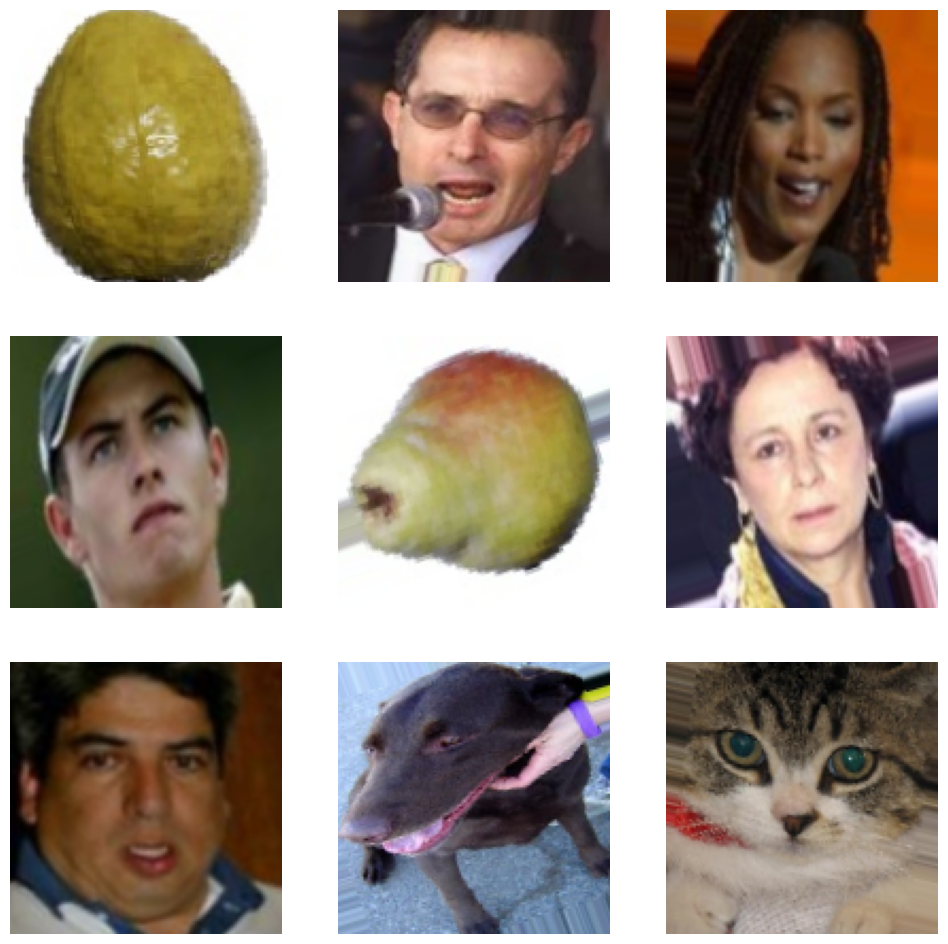

In [9]:
images, labels = next(train_generator)

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()

In [15]:
baseline_model = Sequential()

baseline_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
baseline_model.add(MaxPooling2D(2,2))

baseline_model.add(Conv2D(64, (3,3), activation='relu'))
baseline_model.add(MaxPooling2D(2,2))

baseline_model.add(Conv2D(128, (3,3), activation='relu'))
baseline_model.add(MaxPooling2D(2,2))

baseline_model.add(Flatten())

baseline_model.add(Dense(256, activation='relu'))
baseline_model.add(Dense(128, activation='relu'))
baseline_model.add(Dense(64, activation='relu'))

baseline_model.add(Dense(len(classes), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,704 (25.02 MB)

 Trainable params: 6,557,704 (25.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


173/173 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
173/173 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
 42/173 ━━━━━━━━━━━━━━━━━━━━ 2:48 1s/step - accuracy: 1.0000 - loss: 0.0000e+00

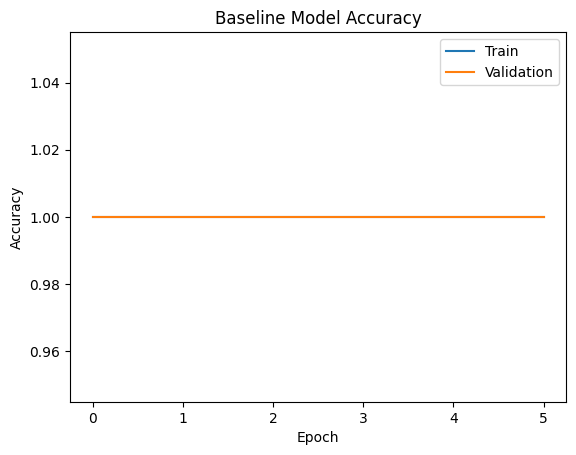

In [21]:
plt.plot(history_baseline.history['accuracy'])
plt.plot(history_baseline.history['val_accuracy'])

plt.title('Baseline Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

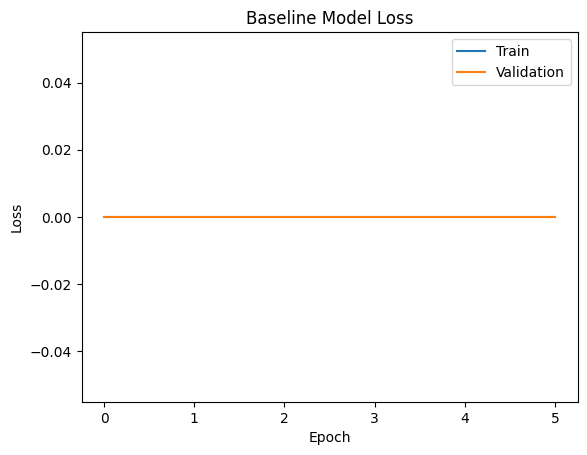

In [22]:
plt.plot(history_baseline.history['loss'])
plt.plot(history_baseline.history['val_loss'])

plt.title('Baseline Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

In [23]:
baseline_loss, baseline_accuracy = baseline_model.evaluate(validation_generator)

print("Baseline Accuracy:", baseline_accuracy)

44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 470ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Baseline Accuracy: 1.0


In [24]:
predictions = baseline_model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 490ms/step


In [25]:
print(classification_report(
    true_classes,
    predicted_classes
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1379

    accuracy                           1.00      1379
   macro avg       1.00      1.00      1.00      1379
weighted avg       1.00      1.00      1.00      1379



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


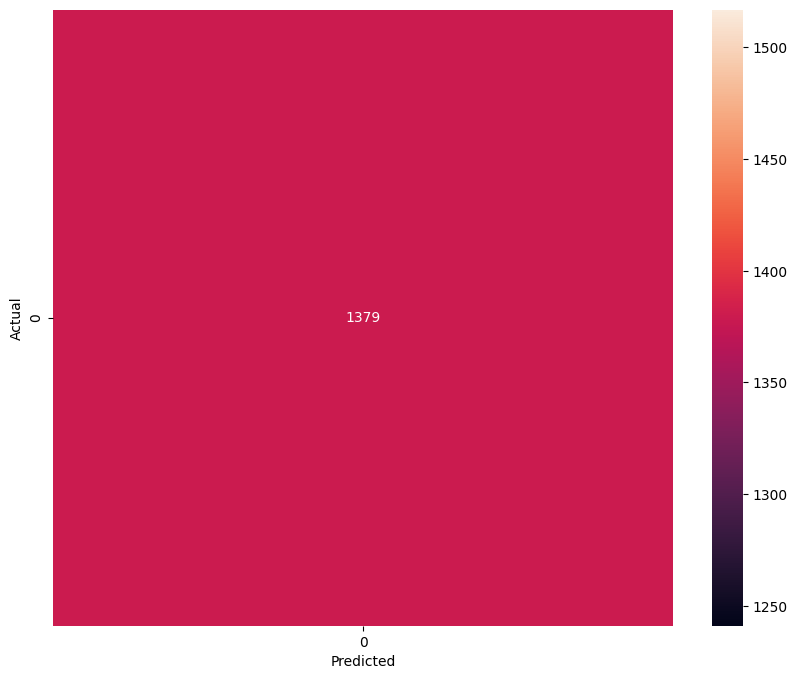

In [26]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [27]:
deep_model = Sequential()

deep_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
deep_model.add(BatchNormalization())

deep_model.add(Conv2D(32, (3,3), activation='relu'))
deep_model.add(MaxPooling2D(2,2))
deep_model.add(Dropout(0.25))

deep_model.add(Conv2D(64, (3,3), activation='relu'))
deep_model.add(BatchNormalization())

deep_model.add(Conv2D(64, (3,3), activation='relu'))
deep_model.add(MaxPooling2D(2,2))
deep_model.add(Dropout(0.25))

deep_model.add(Conv2D(128, (3,3), activation='relu'))
deep_model.add(BatchNormalization())

deep_model.add(Conv2D(128, (3,3), activation='relu'))
deep_model.add(MaxPooling2D(2,2))
deep_model.add(Dropout(0.5))

deep_model.add(Flatten())

deep_model.add(Dense(512, activation='relu'))
deep_model.add(Dropout(0.5))

deep_model.add(Dense(8, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
deep_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_deep = deep_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=[early_stop]
)

In [ ]:
deep_loss, deep_accuracy = deep_model.evaluate(validation_generator)

print("Deep CNN Accuracy:", deep_accuracy)

In [ ]:
models = ['Baseline CNN', 'Deep CNN']
accuracies = [baseline_accuracy, deep_accuracy]

plt.bar(models, accuracies)

plt.ylabel('Accuracy')

plt.show()

In [ ]:
sgd_model = tf.keras.models.clone_model(deep_model)

sgd_model.compile(
    optimizer=SGD(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = sgd_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
transfer_model = Sequential()

transfer_model.add(base_model)

transfer_model.add(GlobalAveragePooling2D())

transfer_model.add(Dense(256, activation='relu'))

transfer_model.add(Dropout(0.5))

transfer_model.add(Dense(8, activation='softmax'))

In [ ]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[early_stop]
)

In [ ]:
transfer_loss, transfer_accuracy = transfer_model.evaluate(validation_generator)

print("Transfer Learning Accuracy:", transfer_accuracy)

In [ ]:
model_names = ['Baseline CNN', 'Deep CNN', 'Transfer Learning']

accuracies = [
    baseline_accuracy,
    deep_accuracy,
    transfer_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(model_names, accuracies)

plt.ylabel('Accuracy')

plt.title('Model Comparison')

plt.show()

In [ ]:
transfer_model.save('vision_model.h5')

In [ ]:
from tensorflow.keras.preprocessing import image

img_path = '/content/sample.jpg'

img = image.load_img(img_path, target_size=(128,128))

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = transfer_model.predict(img_array)

predicted_class = np.argmax(prediction)

print(predicted_class)